

# Week4 MCRefresh Brute Force
### OPIM 5641 - Business Decision Modeling · Module4

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/drdave-teaching/OPIM5641-notebooks/blob/main/3_BruteForce/Week4_MCRefresh_BruteForce.ipynb)

*Run me top to bottom - **Runtime → Run all**. Data loads from a stable link, so there's nothing to upload.*

# Parametric MC simulation (two loops!)
One for working 30 years, one for 10K repetitions.

* You just started a job! you are making 100K. Imagine you have 100K in the bank too. You get a 3% raise for inflation every year.
* You are going to save 5% of your salary.
* We imagine no changes for inflation and salary boost for now.
* The stock market makes an average of 7% (mean) and 19% sd.
* How much money will you have at the end of 30 years?

1. Get it right once (one value)
2. Get it right for 30 years (one simulation, one value - the last value)
3. Get it right for 10K simulations (10k values here, the amount you earned at the end of 30 years, but 10k times.)

After you do Number 3:
1. Do descriptive stats
2. Make a histogram
3. Make a CDF plot


# 🔴Get it right!

In [87]:
# variables
pct_saved = 0.05
stock_return = 0.07 # hard code for now
salary = 100_000 # i make this every year
startingMoney = 100_000 # i have this money in the bank day 1 year 1...


In [88]:
# calculated variables
myContribution = salary*pct_saved
print(myContribution)

5000.0


In [89]:
# add it to my pot of money
print(startingMoney)
myMoney = startingMoney + myContribution
print(myMoney)
myMoney = (1 + stock_return)*myMoney
print(myMoney)

100000
105000.0
112350.0


## 🔴 Get it right for 30 years

In [90]:
# variables
import numpy as np

startingMoney = 100_000 # I always start with this amount
salary = 100_000 # I'm gonna make 100k per year every year (for now)
pct_saved = 0.05
inflation_raise = 1.03 # 3% raise every year

myMoney = startingMoney
results = []
rates = []
for a in np.arange(0,30,1): # start small, 3 years later 30 years
  print('Year:', a)
  # give myself an inflation raise
  salary = (salary * (inflation_raise))
  print('Salary:', salary)

  # every year has a different random (sensible) rate
  stock_return = np.random.normal(loc = 0.07, scale= 0.19) # hard code for now
  print('Rate:', stock_return)
  myContribution = salary*pct_saved
  # add my contribution to exisitng money
  myMoney = myMoney + myContribution
  # apply the rate
  myMoney = (1 + stock_return)*myMoney
  print(myMoney)
  results.append(myMoney)
  rates.append(stock_return)
  print('-------')
print('All done!')

Year: 0
Salary: 103000.0
Rate: 0.36081549251423567
143089.7490378719
-------
Year: 1
Salary: 106090.0
Rate: 0.2512627592425255
185680.19750685006
-------
Year: 2
Salary: 109272.7
Rate: -0.022054354489558142
186928.27866625128
-------
Year: 3
Salary: 112550.881
Rate: 0.03007682602387983
198347.290695973
-------
Year: 4
Salary: 115927.40742999999
Rate: -0.41501801783895514
119420.36349686289
-------
Year: 5
Salary: 119405.2296529
Rate: 0.21469741354144245
152311.66784495325
-------
Year: 6
Salary: 122987.386542487
Rate: 0.15945405674608182
183728.29238535705
-------
Year: 7
Salary: 126677.00813876161
Rate: 0.11663801022253775
212230.6129462203
-------
Year: 8
Salary: 130477.31838292447
Rate: -0.06999627548041118
203442.48010013252
-------
Year: 9
Salary: 134391.6379344122
Rate: -0.08994404621767627
191259.235779406
-------
Year: 10
Salary: 138423.38707244457
Rate: 0.3065841480892157
258939.37580871332
-------
Year: 11
Salary: 142576.08868461792
Rate: 0.05292703849830224
280150.3810618357

In [91]:
rates

[0.36081549251423567,
 0.2512627592425255,
 -0.022054354489558142,
 0.03007682602387983,
 -0.41501801783895514,
 0.21469741354144245,
 0.15945405674608182,
 0.11663801022253775,
 -0.06999627548041118,
 -0.08994404621767627,
 0.3065841480892157,
 0.05292703849830224,
 0.3812275628831773,
 0.022924722028286666,
 -0.03447457705764159,
 0.33838168557810167,
 0.15687442421234638,
 0.0640654254637121,
 -0.08585829246660065,
 0.3047929709582342,
 0.23325398957160864,
 0.004337638055113002,
 0.23497914424723618,
 0.12708253883020887,
 0.0753119357513331,
 -0.06644675698402039,
 0.20756735673331733,
 -0.032207197508212784,
 0.1976285616787648,
 -0.31927377337875223]

<Axes: >

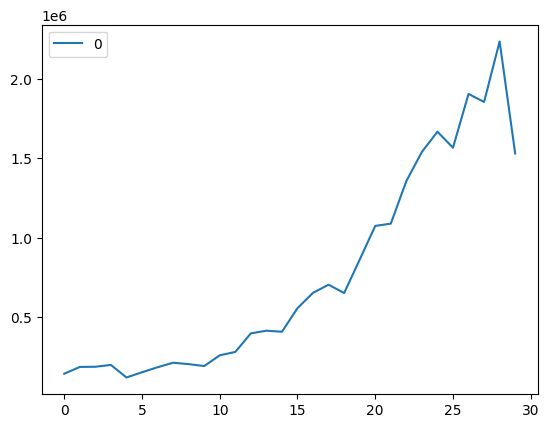

In [92]:
import pandas as pd
results = pd.DataFrame(results)
#rates = pd.DataFrame(rates)
results.plot()
#rates.plot()

# 🔴 10k simulations!

In [98]:
results = []

for b in np.arange(0,10000,1):
  # variables
  startingMoney = 100_000 # I always start with this amount
  salary = 100_000 # I'm gonna make 100k per year every year (for now)
  pct_saved = 0.05
  inflation_raise = 1.03 # 3% raise every year

  myMoney = startingMoney

  for a in np.arange(0,30,1): # start small, 3 years later 30 years
    print('Year:', a)
    # give myself an inflation raise
    salary = (salary * (inflation_raise))
    print('Salary:', salary)

    # every year has a different random (sensible) rate
    stock_return = np.random.normal(loc = 0.07, scale= 0.19) # hard code for now
    print('Rate:', stock_return)
    myContribution = salary*pct_saved
    # add my contribution to exisitng money
    myMoney = myMoney + myContribution
    # apply the rate
    myMoney = (1 + stock_return)*myMoney
    print(myMoney)
    if a == 29:
      results.append(myMoney)
    print('-------')
  print('All done!')
  print(np.shape(results))

Streaming output truncated to the last 5000 lines.
Salary: 112550.881
Rate: -0.0013284501219104072
112087.35336292286
-------
Year: 4
Salary: 115927.40742999999
Rate: 0.23444673871314922
145521.17831132017
-------
Year: 5
Salary: 119405.2296529
Rate: 0.02611060280123282
155446.97260621225
-------
Year: 6
Salary: 122987.386542487
Rate: -0.006261482778533237
160584.50922124705
-------
Year: 7
Salary: 126677.00813876161
Rate: -0.15027342344196457
141834.96629154074
-------
Year: 8
Salary: 130477.31838292447
Rate: 0.27945392622565357
189818.29036221642
-------
Year: 9
Salary: 134391.6379344122
Rate: 0.12469712152918809
221045.57920109775
-------
Year: 10
Salary: 138423.38707244457
Rate: 0.035498260935189214
236059.1716794621
-------
Year: 11
Salary: 142576.08868461792
Rate: -0.16345349688388786
203438.0510177945
-------
Year: 12
Salary: 146853.37134515645
Rate: -0.0760175748400839
194757.68045914886
-------
Year: 13
Salary: 151258.97248551116
Rate: 0.10964711047121331
224504.50145114004
--

## Descriptive Stats

In [99]:
results = pd.DataFrame(results)
results.columns = ['Savings']
results.describe()

,Savings
count,1.000000e+04
mean,1.504309e+06
std,1.502172e+06
min,4.732869e+04
25%,6.292740e+05
50%,1.062214e+06
75%,1.845959e+06
max,2.580127e+07


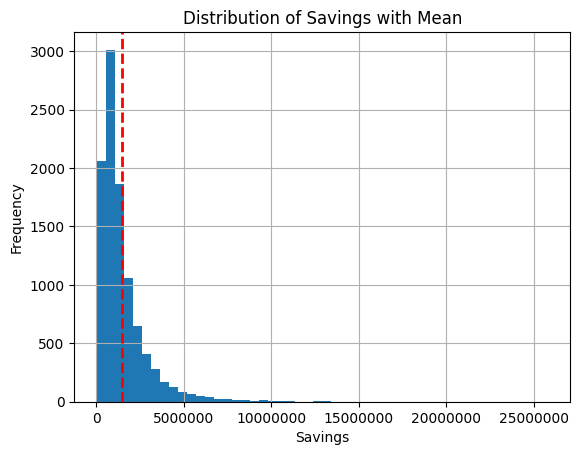

In [103]:
import matplotlib.pyplot as plt

results.hist(bins=50)
mean_savings = results['Savings'].mean()
plt.axvline(mean_savings, color='red', linestyle='dashed', linewidth=2)
plt.title('Distribution of Savings with Mean')
plt.xlabel('Savings')
plt.ylabel('Frequency')
plt.ticklabel_format(style='plain', axis='x')

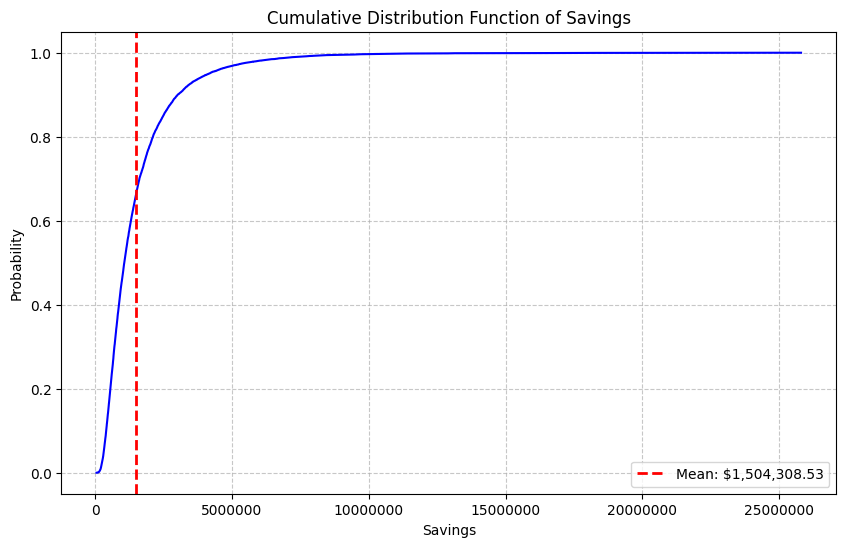

In [110]:
import matplotlib.pyplot as plt
import numpy as np

sorted_savings = np.sort(results['Savings'])
cdf = np.arange(1, len(sorted_savings) + 1) / len(sorted_savings)

plt.figure(figsize=(10, 6))
plt.plot(sorted_savings, cdf, linestyle='-', color='blue')

mean_savings = results['Savings'].mean()
plt.axvline(mean_savings, color='red', linestyle='dashed', linewidth=2, label=f'Mean: ${mean_savings:,.2f}')

plt.title('Cumulative Distribution Function of Savings')
plt.xlabel('Savings')
plt.ylabel('Probability')
plt.grid(True, linestyle='--', alpha=0.7)
plt.ticklabel_format(style='plain', axis='x')
plt.legend()
plt.show()

# 🤖 Brute Force

## Example - Furniture (extracted from the textbook)

**Problem Description:**
Veerman Furniture Company makes three kinds of office furniture: chairs, desks, and tables. Each product requires some labor in the parts fabrication department, the assembly department, and the shipping department. The furniture is sold through a regional distributor, who has estimated the maximum potential sales for each product in the coming quarter. Finally,the accounting department has provided some data showing the profit contributions on each product. The decision problem is to determine the product mix - that is, to **maximize Veerman’s profit for the quarter by choosing production quantities for chairs, desks, and tables**.

The following data summarizes the parameters of the problem:

Department | Chairs | Desks | Tables | Hours Available
--- | --- | --- | --- | ---
Fabrication | 4 | 6 | 2 | 1,850
Assembly | 3 | 5 | 7 | 2,400
Shipping | 3 | 2 | 4 | 1,500

--------------------------------------------------------------------------------
-- | Chairs | Desks | Tables
--- | --- | --- | --- |
Demand Potential | 360 | 300 | 100 |
Profit (USD) | 15 | 24 | 18 |

# Brute Force

In [124]:
for a in ['A1', 'A2']:
  print(a, '-----')
  for b in ['B1', 'B2', 'B3']:
    print(b)

A1 -----
B1
B2
B3
A2 -----
B1
B2
B3


### Hard-coding
It's right, but dangerous... easy to make a mistake and hard to updated.

In [137]:
# initialize some placeholders
best_c = 0
best_d = 0
best_t = 0
best_profit = 0

# 3 nested for loops - one for each decision variables (chairs,desks,tables)
# we are gonna evaluatre 10.8M combinations = 360*300*100
for c in np.arange(0,360+1,1):
  for d in np.arange(0,300+1,1):
    for t in np.arange(0,100+1,1):
      # are all of your constraints valid?
      if(
        c <= 360 and
        d <= 300 and
        t <= 100 and
        4*c + 6*d + 2*t <= 1850 and
        3*c + 5*d + 7*t <= 2400 and
        3*c + 2*d + 4*t <= 1500):
          current_profit = 15*c + 24*d + 18*t
          if current_profit > best_profit:
            best_c = c
            best_d = d
            best_t = t
            best_profit = current_profit

In [138]:
print('best_profit', best_profit)
print('best_c', best_c)
print('best_d', best_d)
print('best_t', best_t)

best_profit 8400
best_c 0
best_d 275
best_t 100
